# EEG Decoding: Cit vs Cyc 

Apoorv Saraogee MSDS 590 - Dr. Srinivasan

This notebook presents the final decoding and interpretability pipeline for Cit vs Cyc classification from Kato EEG data.

## Scope
- Reproducible single-seed baseline run (configured by `PRIMARY_SEED`)
- Temporal, spatial, and spatiotemporal occlusion analyses
- Class-specific interpretability summaries

## Notes for Public Sharing
- Paths are repository-relative (no local/private absolute paths).
- Outputs are intentionally retained for transparent reporting.
- Exploratory side analyses not used in the thesis narrative were removed from this public version.

## 1. Data

In [1]:
import os
from pathlib import Path

os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')

import h5py
import mne
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from tqdm.auto import tqdm

BASE_DIR = Path('Kato_et_al')
PROC_DIR = BASE_DIR / 'ProcData' / 'EEG'
CED_PATH = BASE_DIR / 'biosemi64.ced'

EPOCH_TMIN = -0.5
EPOCH_TMAX = 1.5
ANALYSIS_TMIN = 0.0
ANALYSIS_TMAX = 1.5
SPATIAL_WINDOW_MS = 500
RESAMPLE_HZ = 100
N_EEG_CH = 64

ODOR_CIT, ODOR_CYC = 6, 21
TARGET_ODOR_INFO = {
    6: {'smell': 'Cit', 'response_type': 'positive'},
    21: {'smell': 'Cyc', 'response_type': 'negative'},
}

BEST_CFG = {
    'conv_filters': 40,
    'kernel_size': (5, 5),
    'feature_head': 'gap',
    'lstm_units': 384,
    'bidirectional': False,
    'dense_units': 64,
    'dropout': 0.30,
    'lr': 1e-4,
    'batch_size': 64,
    'label_smoothing': 0.00,
}

SEED = 128
np.random.seed(SEED)
tf.random.set_seed(SEED)

def read_biosemi_coordinates(ced_path):
    coord_df = pd.read_csv(ced_path, sep='\t', engine='python')
    coord_df.columns = [str(col).strip() for col in coord_df.columns]

    for col in ['Number', 'X', 'Y', 'Z', 'theta', 'radius', 'datachan']:
        if col in coord_df.columns:
            coord_df[col] = pd.to_numeric(coord_df[col], errors='coerce')

    if 'datachan' in coord_df.columns and coord_df['datachan'].notna().any():
        coord_df = coord_df.loc[coord_df['datachan'] == 1, ['Number', 'labels', 'X', 'Y', 'Z', 'theta', 'radius']].copy()
    else:
        coord_df = coord_df.loc[:63, ['Number', 'labels', 'X', 'Y', 'Z', 'theta', 'radius']].copy()

    coord_df = coord_df.rename(columns={'labels': 'channel'}).sort_values('Number').reset_index(drop=True)
    coord_df['channel'] = coord_df['channel'].astype(str).str.strip()
    coord_df[['X', 'Y', 'Z', 'theta', 'radius']] = coord_df[['X', 'Y', 'Z', 'theta', 'radius']].astype(float)

    theta_rad = np.deg2rad(coord_df['theta'].values)
    coord_df['x2d'] = coord_df['radius'].values * np.sin(theta_rad)
    coord_df['y2d'] = coord_df['radius'].values * np.cos(theta_rad)
    return coord_df

def make_xy_grid_mapping(coord_df, max_dim=25):
    x2d = coord_df['x2d'].values
    y2d = coord_df['y2d'].values
    x_min, x_max = x2d.min(), x2d.max()
    y_min, y_max = y2d.min(), y2d.max()
    x_span = max(x_max - x_min, 1e-8)
    y_span = max(y_max - y_min, 1e-8)

    for n_rows in range(7, max_dim + 1):
        for n_cols in range(7, max_dim + 1):
            if n_rows * n_cols < len(coord_df):
                continue
            col_idx = np.round((x2d - x_min) / x_span * (n_cols - 1)).astype(int)
            row_idx = np.round((y_max - y2d) / y_span * (n_rows - 1)).astype(int)
            if len(set(zip(row_idx.tolist(), col_idx.tolist()))) == len(coord_df):
                return n_rows, n_cols, row_idx, col_idx

    raise RuntimeError('Could not find collision-free grid mapping.')

def epoch_to_2d_grid(epoch_data, row_idx, col_idx, n_rows, n_cols):
    n_times = epoch_data.shape[-1]
    grid = np.zeros((n_rows, n_cols, n_times), dtype=np.float32)
    for ch, (r, c) in enumerate(zip(row_idx, col_idx)):
        grid[r, c, :] = epoch_data[ch]
    return grid

def load_subject_procdata(subject_id, proc_dir=PROC_DIR, ced_path=CED_PATH):
    mat_path = Path(proc_dir) / subject_id / 'erp_v1.mat'
    if not mat_path.exists():
        return pd.DataFrame(), None

    coord_df = read_biosemi_coordinates(ced_path)
    n_rows, n_cols, row_idx, col_idx = make_xy_grid_mapping(coord_df)

    with h5py.File(mat_path, 'r') as f:
        erp = f['erp'][:]
        log = f['log'][:]
        times = f['times'][:].squeeze()

    odor_nums = log[1, :]
    run_nums = log[4, :]

    stride = int(round(500 / RESAMPLE_HZ))
    t_idx = np.where((times >= EPOCH_TMIN * 1000) & (times <= EPOCH_TMAX * 1000))[0]
    time_indices = t_idx[::stride]

    rows = []
    for trial_i in range(erp.shape[0]):
        odor_num = int(odor_nums[trial_i])
        if odor_num not in TARGET_ODOR_INFO:
            continue

        eeg_ch_time = erp[trial_i][time_indices, :N_EEG_CH].T
        odor_info = TARGET_ODOR_INFO[odor_num]
        rows.append({
            'subject': subject_id,
            'run_modality': f"run-{int(run_nums[trial_i]):02d}",
            'trial': int(log[0, trial_i]),
            'odor_number': odor_num,
            'smell': odor_info['smell'],
            'response_type': odor_info['response_type'],
            'data': epoch_to_2d_grid(eeg_ch_time, row_idx, col_idx, n_rows, n_cols),
        })

    if not rows:
        return pd.DataFrame(), None

    metadata = {
        'grid_shape': (n_rows, n_cols),
        'channel_positions': coord_df,
        'row_idx': row_idx,
        'col_idx': col_idx,
    }
    return pd.DataFrame(rows), metadata

def build_kato_cit_cyc_dataframe(proc_dir=PROC_DIR, ced_path=CED_PATH):
    all_dfs, metadata = [], None
    for subject_dir in sorted(Path(proc_dir).iterdir()):
        if not subject_dir.is_dir():
            continue
        df, meta = load_subject_procdata(subject_dir.name, proc_dir, ced_path)
        if not df.empty:
            all_dfs.append(df)
            if metadata is None:
                metadata = meta
    if not all_dfs:
        return pd.DataFrame(), None
    return pd.concat(all_dfs, ignore_index=True), metadata

def add_zero_crossing_channel(x):
    arr = np.asarray(x, dtype=np.float32)
    eeg = arr[..., 0]
    sign = np.sign(eeg)
    sign[sign == 0] = 1
    zc = np.zeros_like(eeg, dtype=np.float32)
    zc[:, 1:, :, :] = (sign[:, 1:, :, :] * sign[:, :-1, :, :] < 0).astype(np.float32)
    return np.concatenate([arr, zc[..., np.newaxis]], axis=-1)

def build_best_model(input_shape, cfg):
    inp = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(cfg['conv_filters'], cfg['kernel_size'], activation='relu', padding='same'))(inp)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling2D((2, 2)))(x)
    if cfg['feature_head'] == 'gap':
        x = tf.keras.layers.TimeDistributed(tf.keras.layers.GlobalAveragePooling2D())(x)
    else:
        x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)
    lstm_layer = tf.keras.layers.LSTM(cfg['lstm_units'], return_sequences=False, dropout=cfg['dropout'])
    x = tf.keras.layers.Bidirectional(lstm_layer)(x) if cfg['bidirectional'] else lstm_layer(x)
    x = tf.keras.layers.Dense(cfg['dense_units'], activation='relu')(x)
    x = tf.keras.layers.Dropout(cfg['dropout'])(x)
    out = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=cfg['lr']),
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=cfg['label_smoothing']),
        metrics=['accuracy'],
    )
    return model

def build_time_axis(n_timepoints, epoch_tmin=EPOCH_TMIN, fs=RESAMPLE_HZ):
    return epoch_tmin + np.arange(n_timepoints, dtype=np.float64) / float(fs)

def select_analysis_bin_indices(n_timepoints, n_bins=28, analysis_tmin=ANALYSIS_TMIN, analysis_tmax=ANALYSIS_TMAX):
    time_axis = build_time_axis(n_timepoints)
    valid_idx = np.where((time_axis >= analysis_tmin) & (time_axis <= analysis_tmax))[0]
    if valid_idx.size < n_bins:
        raise RuntimeError(
            f'Only {valid_idx.size} valid timepoints in [{analysis_tmin}, {analysis_tmax}]s, but n_bins={n_bins}.'
        )
    pick = np.linspace(0, valid_idx.size - 1, n_bins, dtype=int)
    selected_idx = valid_idx[pick]
    selected_times = time_axis[selected_idx]
    return selected_idx, selected_times

def make_citcyc_split(multi_df, n_bins=28, seed=17, test_size=0.25, analysis_tmin=ANALYSIS_TMIN, analysis_tmax=ANALYSIS_TMAX):
    df_cit = multi_df[multi_df['odor_number'] == ODOR_CIT].copy()
    df_cyc = multi_df[multi_df['odor_number'] == ODOR_CYC].copy()

    X_cit = np.transpose(np.stack(df_cit['data'].values).astype(np.float32), (0, 3, 1, 2))[..., np.newaxis]
    X_cyc = np.transpose(np.stack(df_cyc['data'].values).astype(np.float32), (0, 3, 1, 2))[..., np.newaxis]

    idx, selected_times = select_analysis_bin_indices(
        n_timepoints=X_cit.shape[1],
        n_bins=n_bins,
        analysis_tmin=analysis_tmin,
        analysis_tmax=analysis_tmax,
    )
    X_cit = X_cit[:, idx, :, :, :]
    X_cyc = X_cyc[:, idx, :, :, :]

    n_min = min(X_cit.shape[0], X_cyc.shape[0])
    rng = np.random.default_rng(seed)
    cit_sel = rng.choice(X_cit.shape[0], n_min, replace=False)
    cyc_sel = rng.choice(X_cyc.shape[0], n_min, replace=False)

    X = np.concatenate([X_cit[cit_sel], X_cyc[cyc_sel]], axis=0)
    y = np.concatenate([np.zeros(n_min, dtype=np.int32), np.ones(n_min, dtype=np.int32)])

    shuf = rng.permutation(len(y))
    X, y = X[shuf], y[shuf]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed, stratify=y)
    return X_train, X_test, y_train, y_test, selected_times

print('Helpers loaded.')

Helpers loaded.


In [3]:
# Standalone pleasantness summary by odor (from ProcData logs)
from pathlib import Path
import h5py
import pandas as pd

if 'PROC_DIR' in globals():
    proc_dir_local = Path(PROC_DIR)
else:
    proc_dir_local = Path('Kato_et_al') / 'ProcData' / 'EEG'

if not proc_dir_local.exists():
    raise FileNotFoundError(f'ProcData EEG directory not found: {proc_dir_local}')

pleasant_rows = []

for subject_dir in sorted(proc_dir_local.iterdir()):
    if not subject_dir.is_dir():
        continue

    mat_path = subject_dir / 'erp_v1.mat'
    if not mat_path.exists():
        continue

    with h5py.File(mat_path, 'r') as f:
        log = f['log'][:]

    odor_nums = log[1, :].astype(int)
    pleas_ratings = log[2, :].astype(float)

    for odor_num, ple in zip(odor_nums, pleas_ratings):
        pleasant_rows.append({
            'subject': subject_dir.name,
            'odor_number': int(odor_num),
            'pleasantness_rating': float(ple),
        })

pleasant_df = pd.DataFrame(pleasant_rows)
if pleasant_df.empty:
    raise RuntimeError('No pleasantness values found in ProcData logs.')

pleasant_by_odor = (
    pleasant_df
    .groupby('odor_number', as_index=False)['pleasantness_rating']
    .mean()
    .rename(columns={'pleasantness_rating': 'avg_pleasantness'})
    .sort_values('avg_pleasantness', ascending=False)
)

odor_label_map = globals().get(
    'TARGET_ODOR_INFO',
    {6: {'smell': 'Cit'}, 21: {'smell': 'Cyc'}}
)
pleasant_by_odor['odor_label'] = pleasant_by_odor['odor_number'].map(
    lambda x: odor_label_map[x]['smell'] if x in odor_label_map else f'odor_{x}'
)

print(f'Using ProcData directory: {proc_dir_local}')
print(f'Total trials with pleasantness ratings: {len(pleasant_df)}')
print('\nAverage pleasantness by odor:')
print(pleasant_by_odor[['odor_number', 'odor_label', 'avg_pleasantness']].to_string(index=False))

Using ProcData directory: Kato_et_al/ProcData/EEG
Total trials with pleasantness ratings: 6232

Average pleasantness by odor:
 odor_number odor_label  avg_pleasantness
           6        Cit          3.506452
           2     odor_2          3.353870
           7     odor_7          3.193861
          17    odor_17          2.958333
          10    odor_10          2.924559
           9     odor_9          2.876404
           3     odor_3          2.822504
          16    odor_16          2.543372
          22    odor_22          1.945600
          21        Cyc          1.372392


In [9]:
# Standalone 2D EEG grid creation and inspection (table output only)
from pathlib import Path
import numpy as np
import pandas as pd

if 'CED_PATH' in globals():
    ced_path_local = Path(CED_PATH)
else:
    ced_path_local = Path('Kato_et_al') / 'biosemi64.ced'

if not ced_path_local.exists():
    raise FileNotFoundError(f'CED file not found: {ced_path_local}')

if 'read_biosemi_coordinates' in globals() and 'make_xy_grid_mapping' in globals():
    coord_df_grid = read_biosemi_coordinates(ced_path_local)
    n_rows_grid, n_cols_grid, row_idx_grid, col_idx_grid = make_xy_grid_mapping(coord_df_grid)
else:
    def _read_biosemi_coordinates_local(ced_path):
        coord_df = pd.read_csv(ced_path, sep='\t', engine='python')
        coord_df.columns = [str(col).strip() for col in coord_df.columns]
        for col in ['Number', 'X', 'Y', 'Z', 'theta', 'radius', 'datachan']:
            if col in coord_df.columns:
                coord_df[col] = pd.to_numeric(coord_df[col], errors='coerce')
        if 'datachan' in coord_df.columns and coord_df['datachan'].notna().any():
            coord_df = coord_df.loc[coord_df['datachan'] == 1, ['Number', 'labels', 'X', 'Y', 'Z', 'theta', 'radius']].copy()
        else:
            coord_df = coord_df.loc[:63, ['Number', 'labels', 'X', 'Y', 'Z', 'theta', 'radius']].copy()
        coord_df = coord_df.rename(columns={'labels': 'channel'}).sort_values('Number').reset_index(drop=True)
        coord_df['channel'] = coord_df['channel'].astype(str).str.strip()
        coord_df[['X', 'Y', 'Z', 'theta', 'radius']] = coord_df[['X', 'Y', 'Z', 'theta', 'radius']].astype(float)
        theta_rad = np.deg2rad(coord_df['theta'].values)
        coord_df['x2d'] = coord_df['radius'].values * np.sin(theta_rad)
        coord_df['y2d'] = coord_df['radius'].values * np.cos(theta_rad)
        return coord_df

    def _make_xy_grid_mapping_local(coord_df, max_dim=25):
        x2d = coord_df['x2d'].values
        y2d = coord_df['y2d'].values
        x_min, x_max = x2d.min(), x2d.max()
        y_min, y_max = y2d.min(), y2d.max()
        x_span = max(x_max - x_min, 1e-8)
        y_span = max(y_max - y_min, 1e-8)

        for n_rows in range(7, max_dim + 1):
            for n_cols in range(7, max_dim + 1):
                if n_rows * n_cols < len(coord_df):
                    continue
                col_idx = np.round((x2d - x_min) / x_span * (n_cols - 1)).astype(int)
                row_idx = np.round((y_max - y2d) / y_span * (n_rows - 1)).astype(int)
                if len(set(zip(row_idx.tolist(), col_idx.tolist()))) == len(coord_df):
                    return n_rows, n_cols, row_idx, col_idx

        raise RuntimeError('Could not find collision-free grid mapping.')

    coord_df_grid = _read_biosemi_coordinates_local(ced_path_local)
    n_rows_grid, n_cols_grid, row_idx_grid, col_idx_grid = _make_xy_grid_mapping_local(coord_df_grid)

grid_map_df = coord_df_grid[['channel']].copy()
grid_map_df['row'] = row_idx_grid
grid_map_df['col'] = col_idx_grid
grid_map_df = grid_map_df[['row', 'col', 'channel']].sort_values(['row', 'col']).reset_index(drop=True)

grid_layout_df = pd.DataFrame('', index=range(n_rows_grid), columns=range(n_cols_grid))
for _, r in grid_map_df.iterrows():
    grid_layout_df.at[int(r['row']), int(r['col'])] = str(r['channel'])

print(f'Using CED file: {ced_path_local}')
print(f'2D grid shape: {n_rows_grid} x {n_cols_grid}')
print(f'Channels mapped: {len(grid_map_df)}')

print('\nFull row x col grid map (blank = no electrode):')
print(grid_layout_df.to_string())

Using CED file: Kato_et_al/biosemi64.ced
2D grid shape: 10 x 11
Channels mapped: 64

Full row x col grid map (blank = no electrode):
    0    1    2    3    4    5    6    7    8    9    10
0                      Fp1  Fpz  Fp2                    
1            AF7  AF3       AFz       AF4  AF8          
2        F7   F5   F3   F1   Fz   F2   F4   F6   F8     
3  FT7  FC5       FC3  FC1  FCz  FC2  FC4       FC6  FT8
4   T7   C5   C3        C1   Cz   C2        C4   C6   T8
5  TP7  CP5       CP3  CP1  CPz  CP2  CP4       CP6  TP8
6        P7   P5   P3   P1   Pz   P2   P4   P6   P8     
7   P9       PO7       PO3  POz  PO4       PO8       P10
8                       O1   Oz   O2                    
9                            Iz                         


## 2. Model

In [10]:
# Standalone model configuration + architecture summary (HTML-export friendly)
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf

# Resolve config: use existing BEST_CFG if present, otherwise use publication defaults.
cfg_local = dict(globals().get('BEST_CFG', {
    'conv_filters': 40,
    'kernel_size': (5, 5),
    'feature_head': 'gap',
    'lstm_units': 384,
    'bidirectional': False,
    'dense_units': 64,
    'dropout': 0.30,
    'lr': 1e-4,
    'batch_size': 64,
    'label_smoothing': 0.00,
}))

# Resolve input shape robustly.
if 'X_tr_28' in globals() and hasattr(X_tr_28, 'shape') and len(X_tr_28.shape) == 5:
    input_shape_local = tuple(X_tr_28.shape[1:])
    shape_source = 'X_tr_28 in memory'
elif Path('kato_cit_cyc_grid2d_events.pkl').exists():
    _df_local = pd.read_pickle('kato_cit_cyc_grid2d_events.pkl')
    if _df_local.empty or 'data' not in _df_local.columns:
        raise RuntimeError('kato_cit_cyc_grid2d_events.pkl exists but has no usable data column.')
    _sample = np.asarray(_df_local.iloc[0]['data'], dtype=np.float32)  # (H, W, T)
    # Match the notebook convention: 28 selected post-stimulus bins, 2 channels (EEG + zero-crossing)
    input_shape_local = (28, int(_sample.shape[0]), int(_sample.shape[1]), 2)
    shape_source = 'inferred from kato_cit_cyc_grid2d_events.pkl'
else:
    # Last-resort fallback based on known publication setup
    input_shape_local = (28, 12, 11, 2)
    shape_source = 'hardcoded fallback (publication defaults)'

# Build function fallback if helper cell was not run.
if 'build_best_model' in globals():
    model_local = build_best_model(input_shape_local, cfg_local)
else:
    inp = tf.keras.layers.Input(shape=input_shape_local)
    x = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Conv2D(cfg_local['conv_filters'], cfg_local['kernel_size'], activation='relu', padding='same')
    )(inp)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.BatchNormalization())(x)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling2D((2, 2)))(x)
    if cfg_local['feature_head'] == 'gap':
        x = tf.keras.layers.TimeDistributed(tf.keras.layers.GlobalAveragePooling2D())(x)
    else:
        x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)
    lstm_layer = tf.keras.layers.LSTM(cfg_local['lstm_units'], return_sequences=False, dropout=cfg_local['dropout'])
    x = tf.keras.layers.Bidirectional(lstm_layer)(x) if cfg_local['bidirectional'] else lstm_layer(x)
    x = tf.keras.layers.Dense(cfg_local['dense_units'], activation='relu')(x)
    x = tf.keras.layers.Dropout(cfg_local['dropout'])(x)
    out = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model_local = tf.keras.Model(inp, out)
    model_local.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=cfg_local['lr']),
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=cfg_local['label_smoothing']),
        metrics=['accuracy'],
    )

print(f'Input shape source: {shape_source}')
print(f'Input shape used: {input_shape_local}')

cfg_df = pd.DataFrame([{'parameter': k, 'value': str(v)} for k, v in cfg_local.items()])
print('\nModel configuration:')
print(cfg_df.to_string(index=False))

print('\nModel summary:')
model_local.summary()

Input shape source: inferred from kato_cit_cyc_grid2d_events.pkl
Input shape used: (28, 10, 11, 2)

Model configuration:
      parameter  value
   conv_filters     40
    kernel_size (5, 5)
   feature_head    gap
     lstm_units    384
  bidirectional  False
    dense_units     64
        dropout    0.3
             lr 0.0001
     batch_size     64
label_smoothing    0.0

Model summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 10, 11, 2)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 28, 10, 11, 40) │         2,040 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 28, 10, 11, 40) │           160 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 28, 5, 5, 40)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 28, 40)         │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 384)            │       652,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 679,705 (2.59 MB)

 Trainable params: 679,625 (2.59 MB)

 Non-trainable params: 80 (320.00 B)

Using existing pickle cache (set FORCE_REBUILD_FROM_PROCDATA=True to rebuild from ProcData).
Loaded existing dataframe from kato_cit_cyc_grid2d_events.pkl with 1243 events.
Selected 28 bins: 0.000s to 1.490s
First 10 bin times (s): [0.0, 0.05, 0.11, 0.16, 0.22, 0.27, 0.33, 0.38, 0.44, 0.49]
Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.5067 - loss: 0.6985 - val_accuracy: 0.5161 - val_loss: 0.6914
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 903ms/step - accuracy: 0.5202 - loss: 0.6937 - val_accuracy: 0.5269 - val_loss: 0.6923
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 901ms/step - accuracy: 0.5269 - loss: 0.6917 - val_accuracy: 0.5323 - val_loss: 0.6919
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 904ms/step - accuracy: 0.5255 - loss: 0.6904 - val_accuracy: 0.5430 - val_loss: 0.6924
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 945ms/step - accuracy: 0.5215 - loss: 0.6942 - val_accuracy: 0.5108 - val_loss: 0.6946
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 904ms/step - accuracy: 0

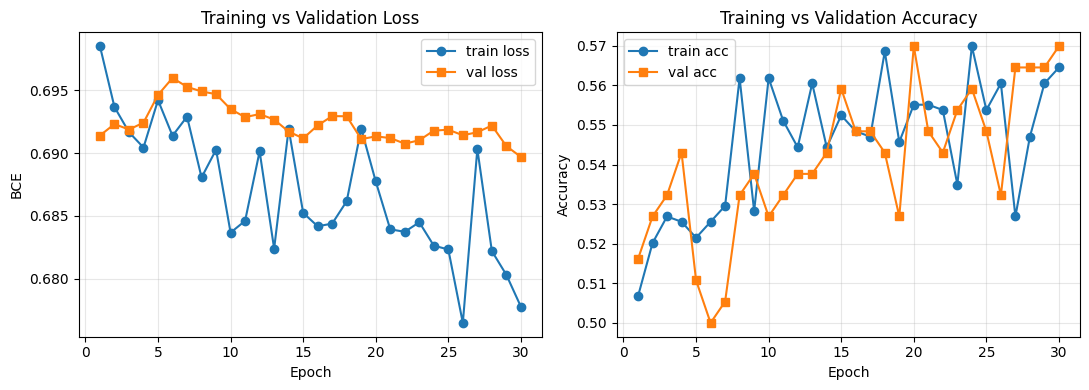

In [2]:
USE_PICKLE_IF_AVAILABLE = True
FORCE_REBUILD_FROM_PROCDATA = False

pickle_path = Path('kato_cit_cyc_grid2d_events.pkl')

if FORCE_REBUILD_FROM_PROCDATA:
    print('FORCE_REBUILD_FROM_PROCDATA=True -> rebuilding from ProcData and refreshing pickle cache.')
    multi_df, kato_metadata = build_kato_cit_cyc_dataframe()
    if multi_df.empty:
        raise RuntimeError('No Cit/Cyc events found. Check ProcData paths.')
    multi_df.to_pickle(pickle_path)
    print(f'Built dataframe from ProcData and saved {pickle_path} with {len(multi_df)} events.')

elif USE_PICKLE_IF_AVAILABLE and pickle_path.exists():
    print('Using existing pickle cache (set FORCE_REBUILD_FROM_PROCDATA=True to rebuild from ProcData).')
    multi_df = pd.read_pickle(pickle_path)
    coord_df = read_biosemi_coordinates(CED_PATH)
    _, _, row_idx, col_idx = make_xy_grid_mapping(coord_df)
    kato_metadata = {
        'channel_positions': coord_df,
        'row_idx': row_idx,
        'col_idx': col_idx,
    }
    print(f'Loaded existing dataframe from {pickle_path} with {len(multi_df)} events.')

else:
    print('No usable pickle cache -> building directly from ProcData.')
    multi_df, kato_metadata = build_kato_cit_cyc_dataframe()
    if multi_df.empty:
        raise RuntimeError('No Cit/Cyc events found. Check ProcData paths.')
    multi_df.to_pickle(pickle_path)
    print(f'Built dataframe from ProcData and saved {pickle_path} with {len(multi_df)} events.')


PRIMARY_SEED = 42

X_tr_28_raw, X_te_28_raw, y_tr_28, y_te_28, bin_times_28 = make_citcyc_split(
    multi_df=multi_df, n_bins=28, seed=PRIMARY_SEED,
    analysis_tmin=ANALYSIS_TMIN, analysis_tmax=ANALYSIS_TMAX)
X_tr_28 = add_zero_crossing_channel(X_tr_28_raw)
X_te_28 = add_zero_crossing_channel(X_te_28_raw)

print(f'Selected {len(bin_times_28)} bins: {bin_times_28.min():.3f}s to {bin_times_28.max():.3f}s')
print('First 10 bin times (s):', np.round(bin_times_28[:10], 3).tolist())

tf.keras.backend.clear_session()
ref_model = build_best_model(
    (X_tr_28.shape[1], X_tr_28.shape[2], X_tr_28.shape[3], X_tr_28.shape[4]), BEST_CFG)

history = ref_model.fit(
    X_tr_28, y_tr_28, validation_split=0.2,
    epochs=30, batch_size=BEST_CFG['batch_size'], verbose=1)

base_pred = (ref_model.predict(X_te_28, verbose=0).ravel() >= 0.5).astype(int)
base_acc = float(accuracy_score(y_te_28, base_pred))
base_f1 = float(f1_score(y_te_28, base_pred, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_te_28, base_pred)
print(f'\nConfusion Matrix (rows=true, cols=pred):\n{cm}')
print(f'  TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}')


epochs_axis = np.arange(1, len(history.history['loss']) + 1)
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].plot(epochs_axis, history.history['loss'], marker='o', label='train loss')
axs[0].plot(epochs_axis, history.history['val_loss'], marker='s', label='val loss')
axs[0].set_title('Training vs Validation Loss')
axs[0].set_xlabel('Epoch'); axs[0].set_ylabel('BCE')
axs[0].legend(); axs[0].grid(alpha=0.3)

axs[1].plot(epochs_axis, history.history['accuracy'], marker='o', label='train acc')
axs[1].plot(epochs_axis, history.history['val_accuracy'], marker='s', label='val acc')
axs[1].set_title('Training vs Validation Accuracy')
axs[1].set_xlabel('Epoch'); axs[1].set_ylabel('Accuracy')
axs[1].legend(); axs[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [ ]:
# Save trained model weights for reproducibility
MODEL_PATH = f'cit_cyc_cnn_lstm_seed{PRIMARY_SEED}.keras'
ref_model.save(MODEL_PATH)
print(f'Saved model to {MODEL_PATH}')

## 3. Results

In [3]:
# ── Single-seed occlusion analysis ────────────────────────────────────────────
# Re-uses the model and test split already trained in cell 3 — no retraining.

SPLIT_SEEDS = [PRIMARY_SEED]

# Aliases so downstream cells keep working unchanged
m_s           = ref_model
Xte_s         = X_te_28
yte_s         = y_te_28
bin_times_ref = bin_times_28
n_bins_ref    = Xte_s.shape[1]
H_ref, W_ref  = Xte_s.shape[2], Xte_s.shape[3]

bp_s   = (m_s.predict(Xte_s, verbose=0).ravel() >= 0.5).astype(int)
bacc_s = float(accuracy_score(yte_s, bp_s))
bf1_s  = float(f1_score(yte_s, bp_s, zero_division=0))
print(f'Baseline: acc={bacc_s:.4f}, f1={bf1_s:.4f}')

accum_temp = {}
accum_sp   = {}
accum_3d   = {}

for b in tqdm(range(n_bins_ref), desc='Temporal occlusion'):
    Xo = Xte_s.copy()
    Xo[:, b, :, :, :] = 0.0
    po = (m_s.predict(Xo, verbose=0).ravel() >= 0.5).astype(int)
    ao = float(accuracy_score(yte_s, po))
    accum_temp[b] = [abs(bacc_s - ao)]

for i in tqdm(range(H_ref), desc='Spatial occlusion'):
    for j in range(W_ref):
        Xo = Xte_s.copy()
        Xo[:, :, i, j, :] = 0.0
        po = (m_s.predict(Xo, verbose=0).ravel() >= 0.5).astype(int)
        ao = float(accuracy_score(yte_s, po))
        accum_sp[(i, j)] = [abs(bacc_s - ao)]

for b in tqdm(range(n_bins_ref), desc='3D occlusion'):
    for i in range(H_ref):
        for j in range(W_ref):
            Xo = Xte_s.copy()
            Xo[:, b, i, j, :] = 0.0
            po = (m_s.predict(Xo, verbose=0).ravel() >= 0.5).astype(int)
            ao = float(accuracy_score(yte_s, po))
            accum_3d[(b, i, j)] = [abs(bacc_s - ao)]

print('Occlusion done.')

Baseline: acc=0.5903, f1=0.5781


Temporal occlusion:   0%|          | 0/28 [00:00<?, ?it/s]

Spatial occlusion:   0%|          | 0/10 [00:00<?, ?it/s]

3D occlusion:   0%|          | 0/28 [00:00<?, ?it/s]

Occlusion done.


Saved: citcyc_temporal_occlusion_28bin_seed42.csv
Top 10 temporal bins:
 bin_idx  time_s  effect_size_acc  std_effect_size_acc
      22    1.21         0.012903                  0.0
      26    1.43         0.009677                  0.0
      23    1.26         0.009677                  0.0
      19    1.04         0.006452                  0.0
      24    1.32         0.006452                  0.0
      17    0.93         0.006452                  0.0
      13    0.71         0.006452                  0.0
      14    0.77         0.006452                  0.0
       9    0.49         0.003226                  0.0
      10    0.55         0.003226                  0.0


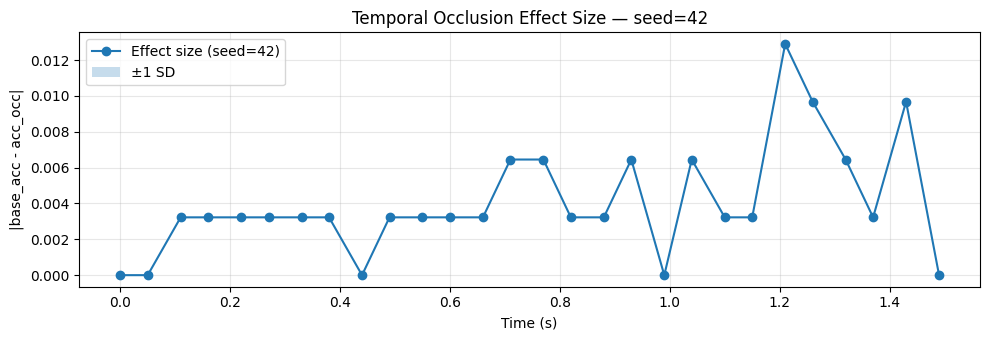

Saved: citcyc_spatial_occlusion_map_seed42.csv


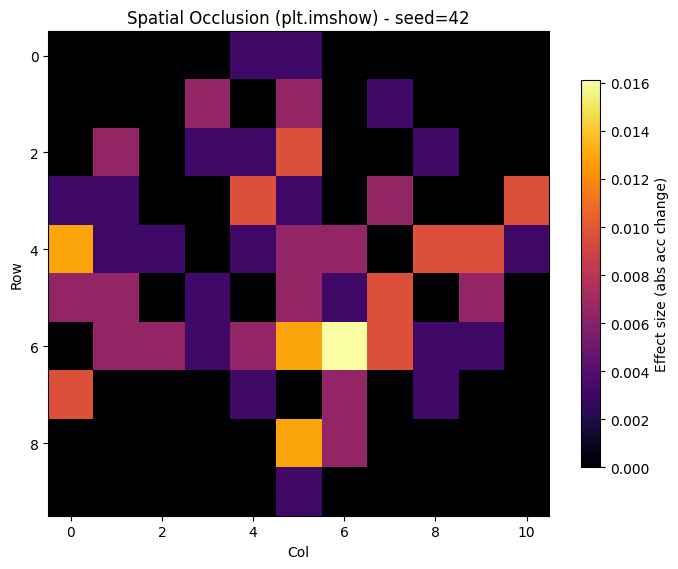

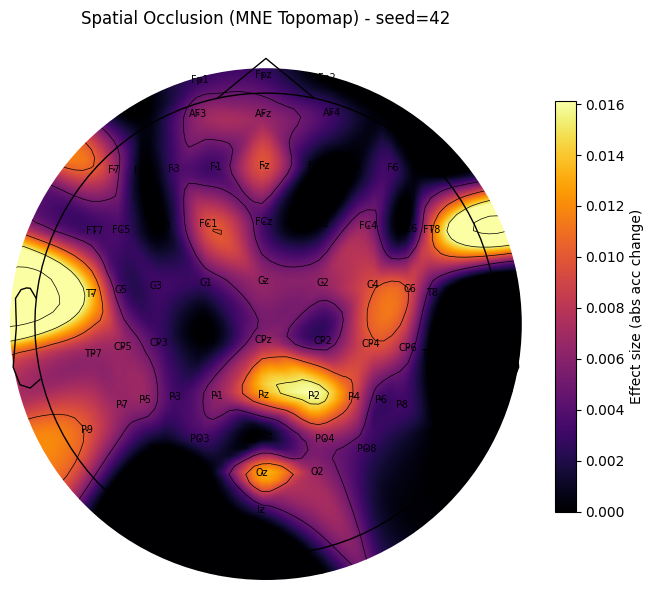

Saved: citcyc_occlusion_3d_bin_row_col_seed42.csv


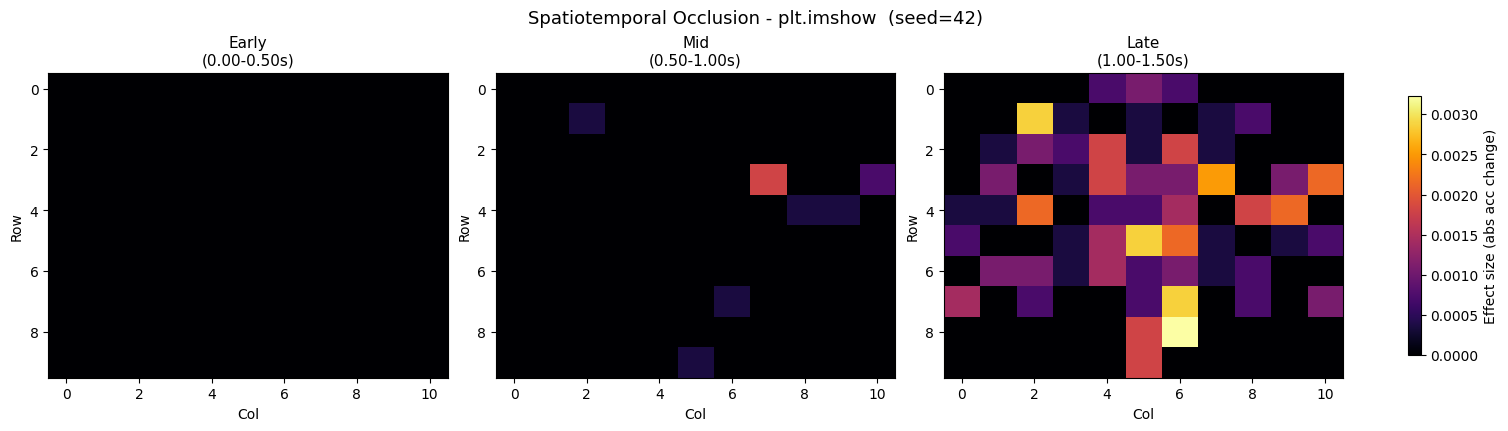

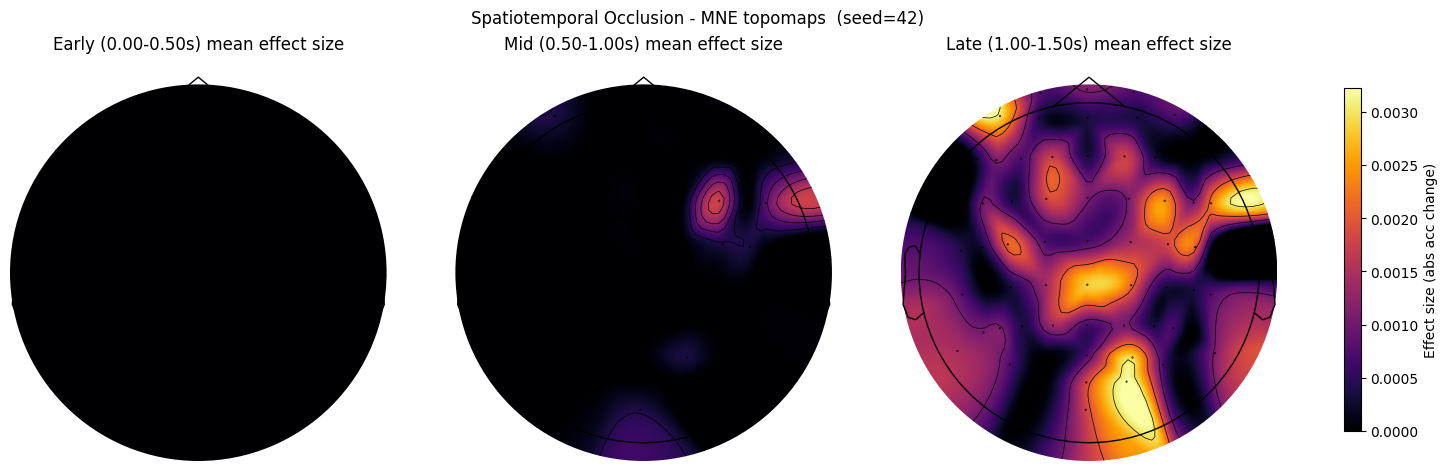

In [5]:
# ── Save CSVs + plots (plt.imshow grids AND MNE topomaps) ─────────────────────

# Temporal
temp_rows_avg = []
for b in sorted(accum_temp):
    vals = accum_temp[b]
    temp_rows_avg.append({
        'bin_idx': b,
        'time_s': float(bin_times_ref[b]),
        'effect_size_acc': float(np.mean(vals)),
        'std_effect_size_acc': float(np.std(vals)),
        'n_seeds': len(vals),
    })
temporal_occ_df = pd.DataFrame(temp_rows_avg)
fp_temporal = f'citcyc_temporal_occlusion_28bin_seed{PRIMARY_SEED}.csv'
temporal_occ_df.to_csv(fp_temporal, index=False)
print(f'Saved: {fp_temporal}')
print('Top 10 temporal bins:')
print(temporal_occ_df.sort_values('effect_size_acc', ascending=False)
      [['bin_idx','time_s','effect_size_acc','std_effect_size_acc']].head(10).to_string(index=False))

# Temporal curve
tmp = temporal_occ_df.sort_values('bin_idx')
plt.figure(figsize=(10, 3.5))
plt.plot(tmp['time_s'], tmp['effect_size_acc'], marker='o', linewidth=1.5,
         label=f'Effect size (seed={SPLIT_SEEDS[0]})')
if 'std_effect_size_acc' in tmp.columns:
    plt.fill_between(tmp['time_s'],
                     tmp['effect_size_acc'] - tmp['std_effect_size_acc'],
                     tmp['effect_size_acc'] + tmp['std_effect_size_acc'],
                     alpha=0.25, label='±1 SD')
plt.title(f'Temporal Occlusion Effect Size — seed={SPLIT_SEEDS[0]}')
plt.xlabel('Time (s)'); plt.ylabel('|base_acc - acc_occ|')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# ── Spatial ─────────────────────────────────────────────────────────────────
spatial_effect_avg = np.full((H_ref, W_ref), np.nan, dtype=np.float32)
for (i, j), vals in accum_sp.items():
    spatial_effect_avg[i, j] = float(np.mean(vals))
spatial_occ_df = pd.DataFrame([
    {'row': i, 'col': j, 'effect_size_acc': float(spatial_effect_avg[i, j])}
    for i in range(H_ref) for j in range(W_ref)
]).sort_values('effect_size_acc', ascending=False).reset_index(drop=True)
fp_spatial = f'citcyc_spatial_occlusion_map_seed{PRIMARY_SEED}.csv'
spatial_occ_df.to_csv(fp_spatial, index=False)
print(f'Saved: {fp_spatial}')

# plt.imshow spatial grid
plt.figure(figsize=(7, 5.8))
im = plt.imshow(spatial_effect_avg, cmap='inferno', aspect='auto')
plt.colorbar(im, shrink=0.8, label='Effect size (abs acc change)')
plt.title(f'Spatial Occlusion (plt.imshow) - seed={SPLIT_SEEDS[0]}')
plt.xlabel('Col'); plt.ylabel('Row')
plt.tight_layout(); plt.show()

# MNE topomap spatial
coord_df_occ  = kato_metadata['channel_positions']
row_idx_occ   = kato_metadata['row_idx']
col_idx_occ   = kato_metadata['col_idx']
ch_names_occ  = coord_df_occ['channel'].tolist()
electrode_importance = np.array(
    [spatial_effect_avg[r, c] for r, c in zip(row_idx_occ, col_idx_occ)],
    dtype=np.float64)
info_occ = mne.create_info(ch_names=ch_names_occ, sfreq=100, ch_types='eeg')
info_occ.set_montage(mne.channels.make_standard_montage('standard_1005'), match_case=False)

fig, ax = plt.subplots(figsize=(7, 6))
im, _ = mne.viz.plot_topomap(
    electrode_importance, info_occ, axes=ax, cmap='inferno', show=False,
    names=ch_names_occ, contours=6)
fig.colorbar(im, ax=ax, shrink=0.75, label='Effect size (abs acc change)')
ax.set_title(f'Spatial Occlusion (MNE Topomap) - seed={SPLIT_SEEDS[0]}')
plt.tight_layout(); plt.show()

# ── 3D spatiotemporal ──────────────────────────────────────────────────────
rows_3d_avg = []
for (b, i, j), vals in sorted(accum_3d.items()):
    rows_3d_avg.append({
        'bin_idx': b, 'time_s': float(bin_times_ref[b]),
        'row': i, 'col': j,
        'effect_size_acc': float(np.mean(vals)),
    })
occ3d_df = pd.DataFrame(rows_3d_avg)
fp_3d = f'citcyc_occlusion_3d_bin_row_col_seed{PRIMARY_SEED}.csv'
occ3d_df.to_csv(fp_3d, index=False)
print(f'Saved: {fp_3d}')

occ_tensor = np.full((n_bins_ref, H_ref, W_ref), np.nan, dtype=np.float32)
for _, r in occ3d_df.iterrows():
    occ_tensor[int(r['bin_idx']), int(r['row']), int(r['col'])] = float(r['effect_size_acc'])

window_sec   = SPATIAL_WINDOW_MS / 1000.0
window_edges = np.arange(ANALYSIS_TMIN, ANALYSIS_TMAX + 1e-9, window_sec)
if window_edges[-1] < ANALYSIS_TMAX:
    window_edges = np.append(window_edges, ANALYSIS_TMAX)

phase_names, phase_maps = [], {}
for w_start, w_end in zip(window_edges[:-1], window_edges[1:]):
    if np.isclose(w_end, ANALYSIS_TMAX):
        bins = np.where((bin_times_ref >= w_start) & (bin_times_ref <= w_end))[0]
    else:
        bins = np.where((bin_times_ref >= w_start) & (bin_times_ref < w_end))[0]
    if bins.size == 0:
        continue
    nm = f'{w_start:.2f}-{w_end:.2f}s'
    phase_names.append(nm)
    phase_maps[nm] = np.nanmean(occ_tensor[bins], axis=0)

# plt.imshow windowed spatiotemporal grids
vmin_g = min(np.nanmin(phase_maps[n]) for n in phase_names)
vmax_g = max(np.nanmax(phase_maps[n]) for n in phase_names)
fig, axs = plt.subplots(1, len(phase_names),
                        figsize=(5.0 * len(phase_names), 4.2), constrained_layout=True)
if len(phase_names) == 1: axs = [axs]
_eml = ['Early', 'Mid', 'Late']
for idx, (ax, name) in enumerate(zip(axs, phase_names)):
    im = ax.imshow(phase_maps[name], cmap='inferno', vmin=vmin_g, vmax=vmax_g, aspect='auto')
    lbl = _eml[idx] if idx < len(_eml) else name
    ax.set_title(f'{lbl}\n({name})', fontsize=11)
    ax.set_xlabel('Col'); ax.set_ylabel('Row')
fig.colorbar(im, ax=axs, shrink=0.85, label='Effect size (abs acc change)')
fig.suptitle(f'Spatiotemporal Occlusion - plt.imshow  (seed={SPLIT_SEEDS[0]})', fontsize=13)
plt.show()

# MNE windowed spatiotemporal topomaps
fig, axs = plt.subplots(1, len(phase_names),
                        figsize=(5.0 * len(phase_names), 4.6), constrained_layout=True)
if len(phase_names) == 1: axs = [axs]
vmin_t = min(np.nanmin(phase_maps[n]) for n in phase_names)
vmax_t = max(np.nanmax(phase_maps[n]) for n in phase_names)
for idx, (ax, name) in enumerate(zip(axs, phase_names)):
    elec_vals = np.array([phase_maps[name][r, c]
                          for r, c in zip(row_idx_occ, col_idx_occ)], dtype=np.float64)
    im, _ = mne.viz.plot_topomap(
        elec_vals, info_occ, axes=ax, cmap='inferno', show=False,
        vlim=(vmin_t, vmax_t), contours=6)
    lbl = _eml[idx] if idx < len(_eml) else name
    ax.set_title(f'{lbl} ({name}) mean effect size')
fig.colorbar(im, ax=axs, shrink=0.85, label='Effect size (abs acc change)')
fig.suptitle(f'Spatiotemporal Occlusion - MNE topomaps  (seed={SPLIT_SEEDS[0]})', fontsize=12)
plt.show()


Cit baseline acc: 0.6194  (n=155)
Cyc baseline acc: 0.5613  (n=155)


Temporal (class-specific):   0%|          | 0/28 [00:00<?, ?it/s]

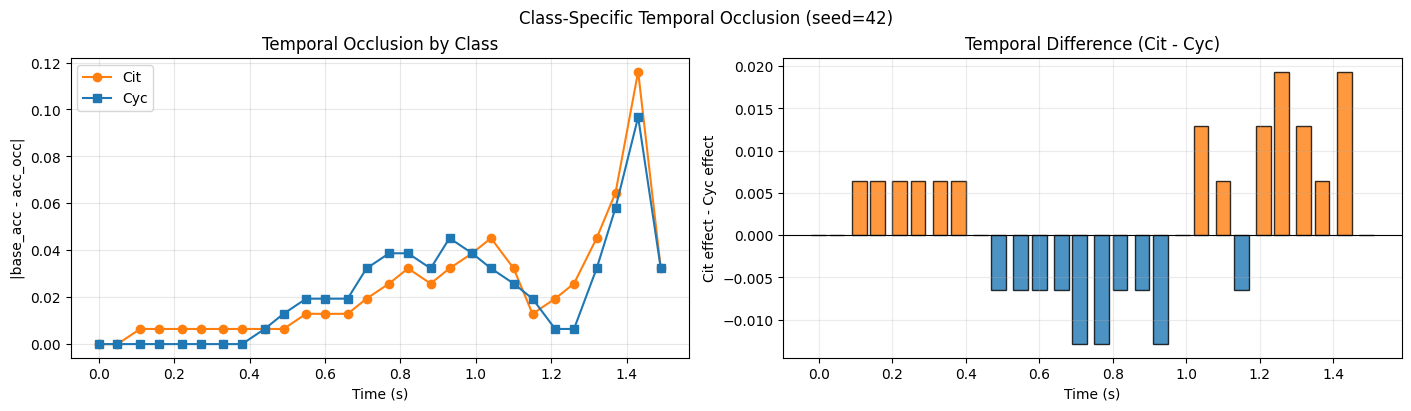

Spatial (class-specific):   0%|          | 0/10 [00:00<?, ?it/s]

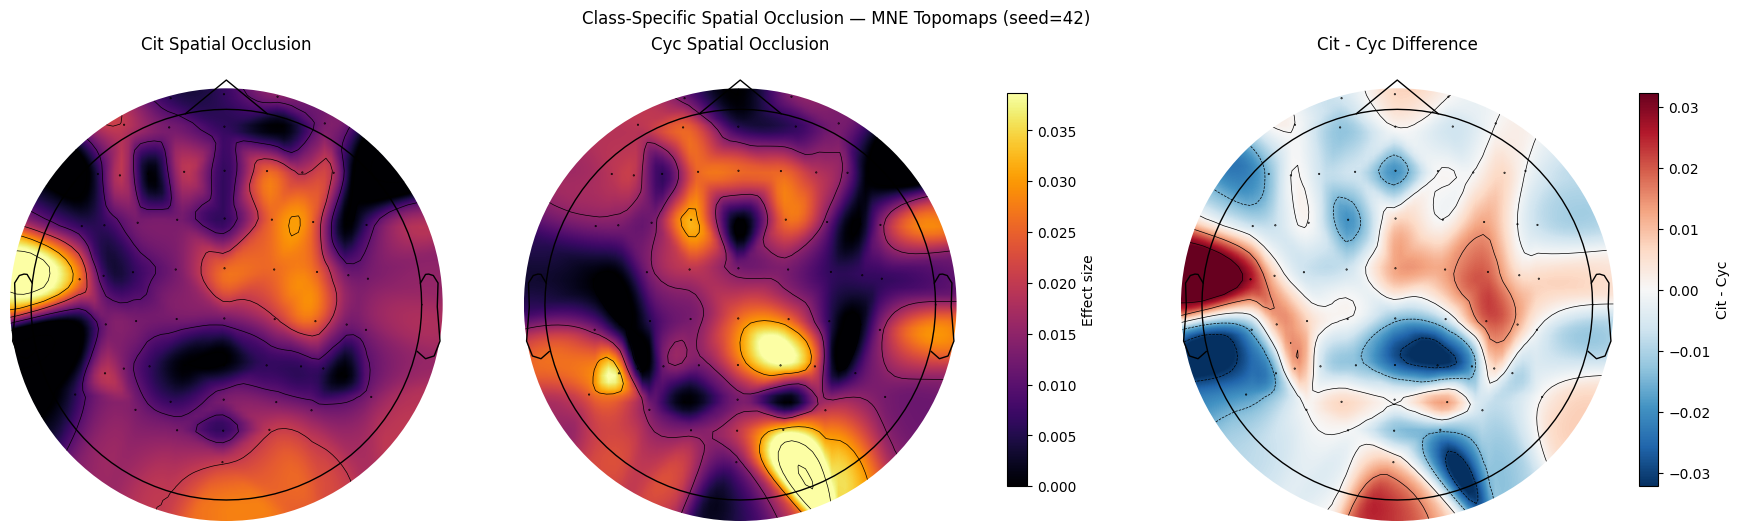

In [6]:
# ── Class-specific temporal + spatial occlusion (focus plots) ─────────────────
# Uses the trained model/test split from earlier cells and computes:
# 1) Temporal occlusion by class (Cit and Cyc, plus difference)
# 2) Spatial class-specific MNE topomaps (Cit, Cyc, Cit−Cyc)

# Prefer the model/split from cell 3, but fall back to existing aliases.
if 'ref_model' in globals() and 'X_te_28' in globals() and 'y_te_28' in globals() and 'bin_times_28' in globals():
    model_cls = ref_model
    Xte_cls = X_te_28
    yte_cls = y_te_28
    t_axis_cls = bin_times_28
elif 'm_s' in globals() and 'Xte_s' in globals() and 'yte_s' in globals() and 'bin_times_ref' in globals():
    model_cls = m_s
    Xte_cls = Xte_s
    yte_cls = yte_s
    t_axis_cls = bin_times_ref
else:
    raise RuntimeError('Missing model/test data. Run cell 3 first (training cell).')

H_ref, W_ref = Xte_cls.shape[2], Xte_cls.shape[3]
n_bins_ref = Xte_cls.shape[1]

cit_idx = np.where(yte_cls == 0)[0]
cyc_idx = np.where(yte_cls == 1)[0]
Xte_cit, yte_cit = Xte_cls[cit_idx], yte_cls[cit_idx]
Xte_cyc, yte_cyc = Xte_cls[cyc_idx], yte_cls[cyc_idx]

base_pred_cit = (model_cls.predict(Xte_cit, verbose=0).ravel() >= 0.5).astype(int)
base_pred_cyc = (model_cls.predict(Xte_cyc, verbose=0).ravel() >= 0.5).astype(int)
base_acc_cit = float(accuracy_score(yte_cit, base_pred_cit))
base_acc_cyc = float(accuracy_score(yte_cyc, base_pred_cyc))
print(f'Cit baseline acc: {base_acc_cit:.4f}  (n={len(cit_idx)})')
print(f'Cyc baseline acc: {base_acc_cyc:.4f}  (n={len(cyc_idx)})')

# ── Temporal occlusion by class ───────────────────────────────────────────────
temp_cit, temp_cyc = [], []
for b in tqdm(range(n_bins_ref), desc='Temporal (class-specific)'):
    Xo_cit = Xte_cit.copy(); Xo_cit[:, b, :, :, :] = 0.0
    Xo_cyc = Xte_cyc.copy(); Xo_cyc[:, b, :, :, :] = 0.0

    acc_cit = float(accuracy_score(yte_cit, (model_cls.predict(Xo_cit, verbose=0).ravel() >= 0.5).astype(int)))
    acc_cyc = float(accuracy_score(yte_cyc, (model_cls.predict(Xo_cyc, verbose=0).ravel() >= 0.5).astype(int)))

    temp_cit.append(abs(base_acc_cit - acc_cit))
    temp_cyc.append(abs(base_acc_cyc - acc_cyc))

temp_cit = np.array(temp_cit)
temp_cyc = np.array(temp_cyc)

fig, axs = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
axs[0].plot(t_axis_cls, temp_cit, marker='o', linewidth=1.5, color='tab:orange', label='Cit')
axs[0].plot(t_axis_cls, temp_cyc, marker='s', linewidth=1.5, color='tab:blue', label='Cyc')
axs[0].set_title('Temporal Occlusion by Class')
axs[0].set_xlabel('Time (s)'); axs[0].set_ylabel('|base_acc - acc_occ|')
axs[0].legend(); axs[0].grid(alpha=0.3)

diff_temp = temp_cit - temp_cyc
axs[1].bar(t_axis_cls, diff_temp, width=0.04,
           color=['tab:orange' if d > 0 else 'tab:blue' for d in diff_temp],
           edgecolor='k', alpha=0.8)
axs[1].axhline(0, color='k', linewidth=0.8)
axs[1].set_title('Temporal Difference (Cit - Cyc)')
axs[1].set_xlabel('Time (s)'); axs[1].set_ylabel('Cit effect - Cyc effect')
axs[1].grid(alpha=0.25)

fig.suptitle(f'Class-Specific Temporal Occlusion (seed={PRIMARY_SEED})', fontsize=12)
plt.show()

# ── Spatial occlusion by class (for MNE topomaps) ────────────────────────────
sp_cit = np.full((H_ref, W_ref), np.nan, dtype=np.float32)
sp_cyc = np.full((H_ref, W_ref), np.nan, dtype=np.float32)

for i in tqdm(range(H_ref), desc='Spatial (class-specific)'):
    for j in range(W_ref):
        Xo_cit = Xte_cit.copy(); Xo_cit[:, :, i, j, :] = 0.0
        Xo_cyc = Xte_cyc.copy(); Xo_cyc[:, :, i, j, :] = 0.0
        acc_cit = float(accuracy_score(yte_cit, (model_cls.predict(Xo_cit, verbose=0).ravel() >= 0.5).astype(int)))
        acc_cyc = float(accuracy_score(yte_cyc, (model_cls.predict(Xo_cyc, verbose=0).ravel() >= 0.5).astype(int)))
        sp_cit[i, j] = abs(base_acc_cit - acc_cit)
        sp_cyc[i, j] = abs(base_acc_cyc - acc_cyc)

sp_diff = sp_cit - sp_cyc

coord_df_cc = kato_metadata['channel_positions']
row_idx_cc  = kato_metadata['row_idx']
col_idx_cc  = kato_metadata['col_idx']
ch_names_cc = coord_df_cc['channel'].tolist()

info_cc = mne.create_info(ch_names=ch_names_cc, sfreq=100, ch_types='eeg')
info_cc.set_montage(mne.channels.make_standard_montage('standard_1005'), match_case=False)

elec_cit = np.array([sp_cit[r, c] for r, c in zip(row_idx_cc, col_idx_cc)], dtype=np.float64)
elec_cyc = np.array([sp_cyc[r, c] for r, c in zip(row_idx_cc, col_idx_cc)], dtype=np.float64)
elec_diff = elec_cit - elec_cyc

vmax_topo = max(np.nanmax(elec_cit), np.nanmax(elec_cyc))
vd_topo = max(abs(np.nanmin(elec_diff)), abs(np.nanmax(elec_diff)))

fig, axs = plt.subplots(1, 3, figsize=(18, 5.2), constrained_layout=True)
im0, _ = mne.viz.plot_topomap(elec_cit, info_cc, axes=axs[0], cmap='inferno', show=False,
                               vlim=(0, vmax_topo), contours=6)
axs[0].set_title('Cit Spatial Occlusion')

im1, _ = mne.viz.plot_topomap(elec_cyc, info_cc, axes=axs[1], cmap='inferno', show=False,
                               vlim=(0, vmax_topo), contours=6)
axs[1].set_title('Cyc Spatial Occlusion')

im2, _ = mne.viz.plot_topomap(elec_diff, info_cc, axes=axs[2], cmap='RdBu_r', show=False,
                               vlim=(-vd_topo, vd_topo), contours=6)
axs[2].set_title('Cit - Cyc Difference')

fig.colorbar(im0, ax=axs[:2], shrink=0.85, label='Effect size')
fig.colorbar(im2, ax=axs[2], shrink=0.85, label='Cit - Cyc')
fig.suptitle(f'Class-Specific Spatial Occlusion — MNE Topomaps (seed={PRIMARY_SEED})', fontsize=12)
plt.show()